In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()


Saving hospital_readmissions_30k.csv to hospital_readmissions_30k.csv


In [3]:
df = pd.read_csv("hospital_readmissions_30k.csv")

In [4]:
df.columns = df.columns.str.strip()

In [5]:
print(df.isnull().sum())

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64


In [6]:
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

In [7]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
df["readmitted_target"] = df["readmitted_30_days"].map({"Yes": 1, "No": 0})

In [9]:
df = df.drop(columns=["readmitted_30_days"], errors='ignore')

In [10]:
categorical_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [11]:
numerical_cols = df.select_dtypes(include='number').columns.drop("readmitted_target")
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [12]:
X = df.drop(columns=["readmitted_target"])
y = df["readmitted_target"]

In [14]:
# Extract feature importance
feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": clf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importances)

                  Feature  Importance
10  discharge_destination    0.366041
0              patient_id    0.137818
3          blood_pressure    0.131079
7            hypertension    0.118768
6                diabetes    0.117125
5                     bmi    0.058893
4             cholesterol    0.048727
2                  gender    0.010934
9          length_of_stay    0.010615
1                     age    0.000000
8        medication_count    0.000000


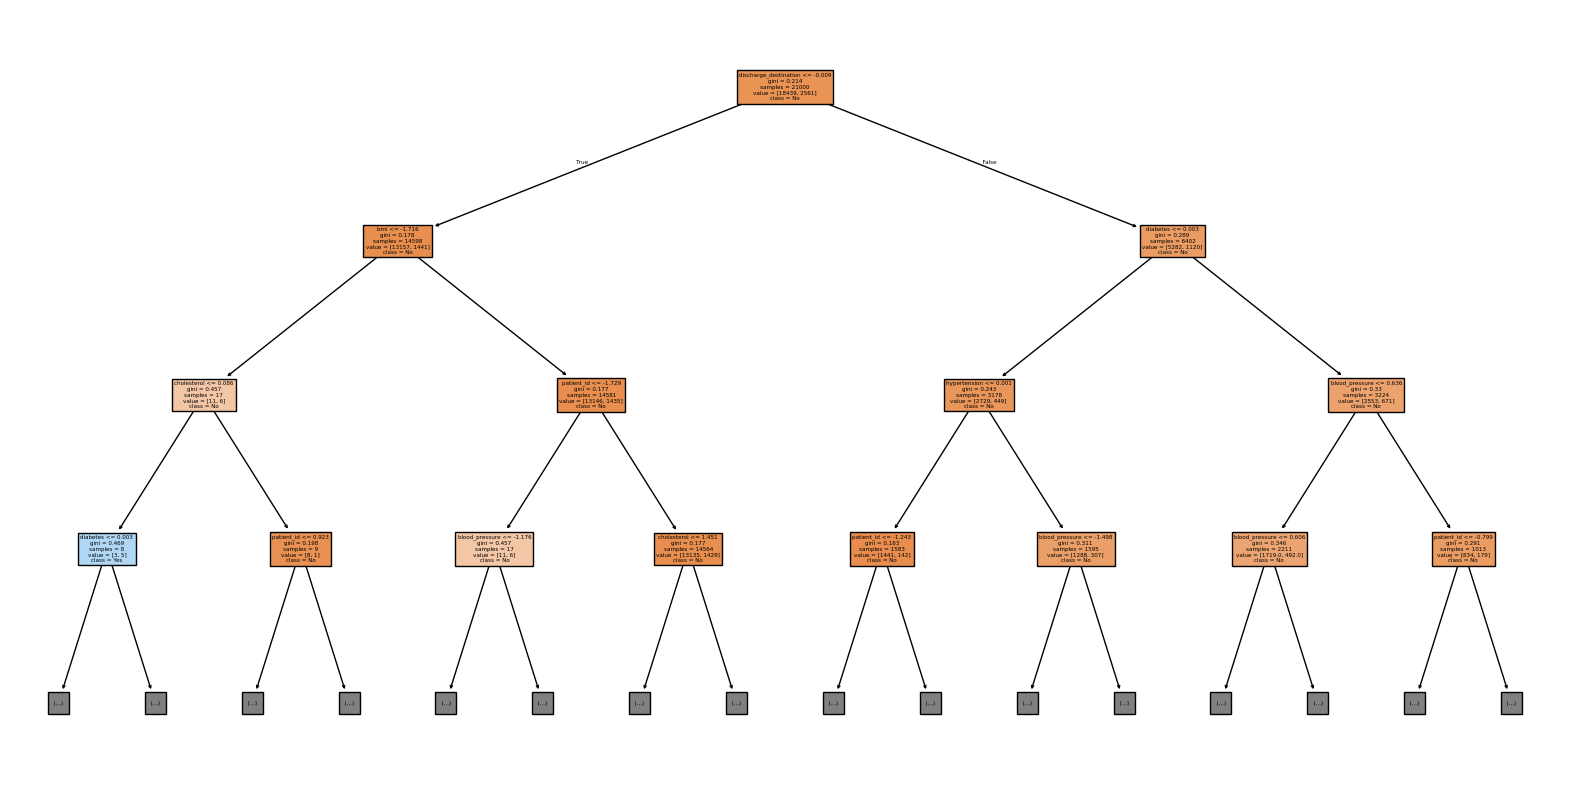

In [15]:
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=["No", "Yes"], filled=True, max_depth=3)
plt.show()

In [16]:
from sklearn.tree import export_text

tree_rules = export_text(clf, feature_names=list(X.columns), max_depth=5)
print(tree_rules)

|--- discharge_destination <= -0.01
|   |--- bmi <= -1.72
|   |   |--- cholesterol <= 0.09
|   |   |   |--- diabetes <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- diabetes >  0.00
|   |   |   |   |--- length_of_stay <= 0.35
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- length_of_stay >  0.35
|   |   |   |   |   |--- class: 1
|   |   |--- cholesterol >  0.09
|   |   |   |--- patient_id <= 0.92
|   |   |   |   |--- class: 0
|   |   |   |--- patient_id >  0.92
|   |   |   |   |--- class: 1
|   |--- bmi >  -1.72
|   |   |--- patient_id <= -1.73
|   |   |   |--- blood_pressure <= -1.18
|   |   |   |   |--- patient_id <= -1.73
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- patient_id >  -1.73
|   |   |   |   |   |--- class: 1
|   |   |   |--- blood_pressure >  -1.18
|   |   |   |   |--- patient_id <= -1.73
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- patient_id >  -1.73
|   |   |   |   |   |--- class: 1
|   |   |--- patient_id >  -1.73
|   |   |   |--- cho

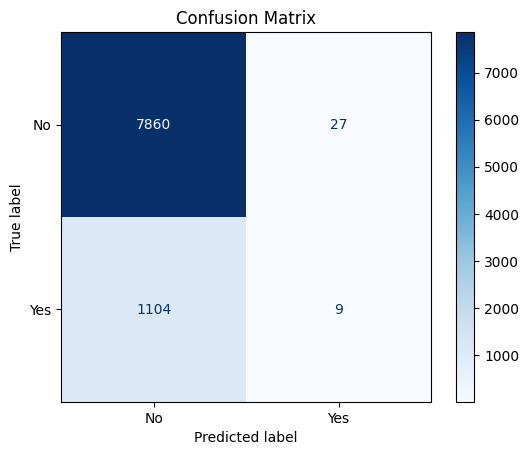

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [13]:
# Split dataset (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Decision Tree
clf = DecisionTreeClassifier(random_state=42, max_depth=5)  # limit depth for interpretability
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")


Accuracy: 0.874
Precision: 0.250
Recall: 0.008
F1 Score: 0.016
ROC-AUC: 0.502
